<a href="https://colab.research.google.com/github/Arfa-Tariq/learning-ai-engineering/blob/main/projects/02-llm-basics/06_Expanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Expanding
In this notebook, we will generate customer service emails that are tailored to each customer's review.

In [1]:
!pip install -q groq

from groq import Groq
from google.colab import userdata

GROQ_API_KEY = userdata.get('groq_key')
client = Groq(api_key=GROQ_API_KEY)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 6.4 MB/s eta 0:00:00


In [2]:
def get_completion(prompt, model="openai/gpt-oss-120b", temperature=0):
  messages = [{"role": "user", "content": prompt}]
  response = client.chat.completions.create(
    model=model,
    messages=messages,
    temperature=temperature,)
  return response.choices[0].message.content

In [4]:
# given the sentiment from the lesson on "inferring",
# and the original customer message, customize the email
sentiment = "negative"

# review for a blender
review = f"""
So, they still had the 17 piece system on seasonal
sale for around $49 in the month of November, about
half off, but for some reason (call it price gouging)
around the second week of December the prices all went
up to about anywhere from between $70-$89 for the same
system. And the 11 piece system went up around $10 or
so in price also from the earlier sale price of $29.
So it looks okay, but if you look at the base, the part
where the blade locks into place doesn’t look as good
as in previous editions from a few years ago, but I
plan to be very gentle with it (example, I crush
very hard items like beans, ice, rice, etc. in the
blender first then pulverize them in the serving size
I want in the blender then switch to the whipping
blade for a finer flour, and use the cross cutting blade
first when making smoothies, then use the flat blade
if I need them finer/less pulpy). Special tip when making
smoothies, finely cut and freeze the fruits and
vegetables (if using spinach-lightly stew soften the
spinach then freeze until ready for use-and if making
sorbet, use a small to medium sized food processor)
that you plan to use that way you can avoid adding so
much ice if at all-when making your smoothie.
After about a year, the motor was making a funny noise.
I called customer service but the warranty expired
already, so I had to buy another one. FYI: The overall
quality has gone done in these types of products, so
they are kind of counting on brand recognition and
consumer loyalty to maintain sales. Got it in about
two days.
"""

In [5]:
prompt = f"""
You are a customer service AI assistant.
Your task is to send an email reply to a valued customer.
Given the customer email delimited by ```, \
Generate a reply to thank the customer for their review.
If the sentiment is positive or neutral, thank them for \
their review.
If the sentiment is negative, apologize and suggest that \
they can reach out to customer service.
Make sure to use specific details from the review.
Write in a concise and professional tone.
Sign the email as `AI customer agent`.
Customer review: ```{review}```
Review sentiment: {sentiment}
"""
response = get_completion(prompt)
print(response)

Subject: We’re Sorry for Your Recent Experience  

Dear [Customer Name],

Thank you for taking the time to share your detailed feedback about the 17‑piece and 11‑piece blender systems. I’m sorry to hear about the price increase you noticed in December, the concerns you have with the blade‑base design, and the motor noise that developed after about a year of use. I understand how frustrating it must be to have to replace the unit after the warranty had already expired.

We value your loyalty and want to make things right. Although the standard warranty period has ended, please reach out to our customer‑service team at support@example.com or call 1‑800‑555‑1234. We would like to review your case and see if we can offer a goodwill solution or a discount on a replacement.

Thank you again for your candid review—it helps us improve our products and pricing policies. We hope to have the opportunity to restore your confidence in our brand.

Sincerely,  
AI customer agent


At higher temperatures the outputs from the model are kind of more random.
You can almost think of it as that at higher temperatures the assistant is more distractible but maybe more creative.

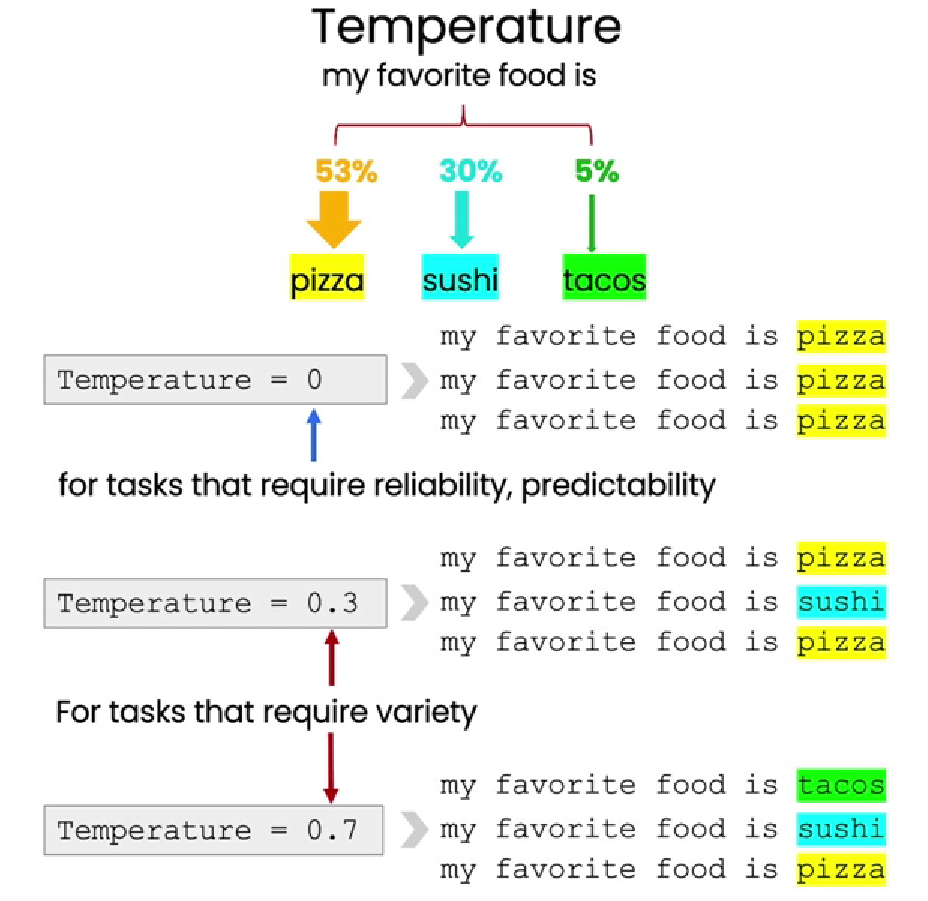

In [6]:
prompt = f"""
You are a customer service AI assistant.
Your task is to send an email reply to a valued customer.
Given the customer email delimited by ```, \
Generate a reply to thank the customer for their review.
If the sentiment is positive or neutral, thank them for \
their review.
If the sentiment is negative, apologize and suggest that \
they can reach out to customer service.
Make sure to use specific details from the review.
Write in a concise and professional tone.
Sign the email as `AI customer agent`.
Customer review: ```{review}```
Review sentiment: {sentiment}
"""
response = get_completion(prompt, temperature=0.7)
print(response)

Subject: Apology Regarding Your Recent Experience  

Dear Valued Customer,

Thank you for taking the time to share your detailed feedback. I’m sorry to hear about the price changes you noticed for the 17‑piece and 11‑piece systems, the concerns you have with the blade‑locking base, and the motor noise that developed after a year of use. I understand how frustrating it must be to encounter these issues, especially after the warranty had expired and you needed to purchase a replacement.

We take product quality and pricing consistency very seriously, and your comments will be forwarded to our product and pricing teams for review. If you would like further assistance—such as troubleshooting the motor issue or exploring any possible goodwill solutions—please feel free to contact our customer service department directly at [customer‑service@example.com] or call 1‑800‑555‑1234. We are committed to helping you resolve this matter.

Thank you again for bringing these concerns to our attention.